# Неустойчивые орбиты вокруг точки $L_1$
в круговой ограниченной задаче трех тел


### Условие задачи


**Дано:**
- движение невесомого тела в системе из двух массивных тел, вращающихся относительно общего центра масс, описывается системой уравнений:

$\begin{cases}
\ddot{x} - 2\dot{y} = \frac{\partial{U}}{\partial{x}} \\
\ddot{y} + 2\dot{x} = \frac{\partial{U}}{\partial{y}} \\
\ddot{z} = \frac{\partial{U}}{\partial{z}} \\
U = \frac{1}{2} (x^2 + y^2) + \frac{\mu_1}{r_1} + \frac{\mu_2}{r_2} \\
r^2_1 = (x + \mu_2)^2 + y^2 + z^2 \\
r^2_2 = (x - \mu_1)^2 + y^2 + z^2
\end{cases}$
<=>
$\begin{cases}
\ddot{x} = 2\dot{y} + x - \left( \mu_1 \frac{x + \mu_2}{r^3_1} + \mu_2 \frac{x - \mu_1}{r^3_2} \right) \\
\ddot{y} = -2\dot{x} + y - \left( \frac{\mu_1}{r^3_1} + \frac{\mu_2}{r^3_2} \right)y \\
\ddot{z} = - \left( \frac{\mu_1}{r^3_1} + \frac{\mu_2}{r^3_2} \right)z \\
r^2_1 = (x + \mu_2)^2 + y^2 + z^2 \\
r^2_2 = (x - \mu_1)^2 + y^2 + z^2
\end{cases}$

- методы Рунге-Кутты для интегрирования систем ОДУ первого порядка, рассмотренные на семинарах
- константы для системы уравнений и метод интегрирования необходимо выбрать самостоятельно в [таблице вариантов](https://docs.google.com/spreadsheets/d/1RvryyiQSz1TTAlwLxOuwmIAaZUZd2cdftZa7yHMPKBw/edit?usp=sharing) так, чтобы не было повторений
- алгоритм вычисления начальной скорости для неустойчивой орбиты вокруг $L_1$, рассмотренный на семинаре
- библиотека математических алгоритмов [Tracker Component Library](https://github.com/USNavalResearchLaboratory/TrackerComponentLibrary/blob/master/Mathematical_Functions/Differential_Equations/RungeKStep.m)
- модули `numba`, `numpy`, `matplotlib`



**Требуется:**
1. Реализовать обобщенный метод Рунге-Кутты на основе таблицы Бутчера для интегрирования систем ОДУ первого порядка:

    - функция для расчета одного шага размера $h$
    - функция для расчета $n$ шагов размера $h$ (1)
    - подготовить таблицу Бутчера из `Tracker Component Library` (определяется вариантом задания)



2. Реализовать алгоритм вычисления начальной скорости для неустойчивой орбиты вокруг $L_1$:

    - модификация функции (1) для досрочной остановки интегрирования при условии пересечения одной из плоскостей
    - функция для расчета начальной скорости $vy_0$ на основе метода бисекции для орбиты, заданной начальным положением $(x_0, 0, z_0)$ и условием ортогональности вектора скорости и плоскости $XOZ$ в начальный момент времени
    
        - $d$ = $90\%$ расстояния от $L_1$ до малого массивного тела 
        - $x_{left} = x_{L1} - d$ - координата левой плоскости, заданной уравнением $x = x_{left}$
        - $x_{right} = x_{L1} + d$ - координата правой плоскости, заданной уравнением $x = x_{right}$


3. Реализовать алгоритм вычисления начальных скоростей орбит, начальные состояния которых заданы на решетке:
    - $(x_0, z_0) \in [x_{min}, x_{max}] \times [z_{min}, z_{max}]$

        - $x_{min} = x_{L1} - d / 3$
        - $x_{max} = x_{L1} + d / 3$
        - $z_{min} = 0.0$
        - $z_{max} = d / 3$

    - количество узлов на решетке $N \times N$


4. Использовать `@njit`, `@cfunc`, `prange` из модуля `numba` для компиляции всех функций и распараллеливания функции расчета на решетке


5. Вычислить начальные скорости и константы Якоби на заданных решетках
    - $J = 2 U - v^2$ - формула для вычисления константы Якоби
    - $h = \pi / 180$ - шаг по времени `t`
    - $x_{L1}$ - координата точки L1 (см. материалы семинара)
    - $[-1.0, 1.0]$ - начальный отрезок для уточнения скоростей методом бисекции (вероятно для некоторых систем этот отрезок не подойдет)


6. Измерить время вычислений


7. Сохранить результаты вычислений в файлах `*.npy` (функцией `np.save`)


8. Построить цветовые карты рассчитанных величин (начальная скорость, константа Якоби):

    - карты должны строиться по сохраненным данным, чтобы отрисовку можно было запустить без повторного выполнения расчетов
    - засечки по осям должны соответствовать координатам $x, z$, где $x$ отсчитывается относительно $x_{L1}$
    - единицы измерений по осям - километры
    - оси должны быть подписаны
    - должен присутствовать `colorbar`
    - должен присутствовать заголовок рисунка


9. Задокументировать все реализованные функции


**Материалы:**
- [Методы Рунге-Кутты](https://ru.wikipedia.org/wiki/Метод_Рунге_—_Кутты)
- [Динамика Солнечной Системы](https://disk.yandex.ru/i/HfJaUW2Sm62td)
- [Tracker Component Library](https://github.com/USNavalResearchLaboratory/TrackerComponentLibrary/blob/master/Mathematical_Functions/Differential_Equations/RungeKStep.m)
- [Mapping of initial conditions for libration point orbits](https://www.dropbox.com/s/wafy1jaylclngbv/Aksenov_ASR.pdf?dl=0)


**Правила оценивания:**

- оценка за корректно выполненные расчеты на решетке размером $(N, N)$:
```
      i  =  1   2    3    4
    N(i) = 40  80  160  320
    g(i) =  1  16   33   50
```
    
- штрафы $p(j)$, баллов:
    - нет цветовых карт - 20
    - карты построены по временным данным (не сохраненным) - 20
    - не сохранены файлы с результатами вычислений - 20
    - нет документации функций - 20
    - не измерено время вычислений - 10
    - менее значимые недоработки - 10

- итоговая оценка за задание = $\sum_{i}g(i) - \sum_{j}{p(j)}$

In [1]:
import numpy as np
mu2 = 1.21574011280745E-02
mu1 = 1 - mu2
R = 384400  # км, среднее расстояние Земля-Луна
# 384 400
mc = np.array([mu2])

In [2]:
from func import crtbp_ode
def g(x: float, mc: np.ndarray) -> float:
    s = np.array([x, 0., 0., 0., 0., 0.])
    return crtbp_ode(0., s, mc)[3] #берём только ускорения (у них индекс 3)

/Users/nikolajgudkov/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
from scipy.optimize import newton
xL1 = newton(g, 0.85 * mu1, args=(mc,), tol=1e-12)
xL1

0.8368815950989779

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from func import crtbp_ode, rk4_nsteps_mod

d = (1- mu1 + xL1) * 0.9
xmin = xL1 - d
xmax = xL1 + d
h = 0.230153307955296  #  шаг по времени

In [6]:
from scipy.optimize import bisect
from func import get_plane
s0 = np.zeros(6)
s0[[0, 2, 4]] = xL1 + d * 0.1, d * 0.1, 0.01
pl = (xL1 - d, xL1 + d)
v_star = bisect(
                get_plane,
                -0.5,
                0.5,
                args = (crtbp_ode, s0, h, mc, 500, (xL1 - d, xL1 + d))
                , xtol=1e-10)
v_star

0.38875386415747926

In [7]:
from numba import cfunc, njit, prange
from tqdm import tqdm
d = (1- mu1 + xL1) * 0.9
xmin = xL1 - d
xmax = xL1 + d
h = np.pi /180

n_steps = 320
z_line = np.linspace(0.0,d/3, n_steps)
x_line = np.linspace(xmin- d/3,xmax+d/3, n_steps)

# @njit(parallel = True)
def get_V_J(x_line, z_line):
    answer_V = np.empty(shape=(len(x_line), len(z_line)))
    answer_J = np.empty(shape=(len(x_line), len(z_line)))
    for i, z in enumerate(tqdm(z_line)):
        for j, x in enumerate(x_line):
            s0 = np.zeros(6)
            s0[0] = x
            s0[2] = z
            s0[4] =  0.01

            v_star = bisect(
                get_plane,
                -5,
                5,
                args = (crtbp_ode, s0, h, mc, 500, (xL1 - d, xL1 + d))
                , xtol=1e-6)
            U = 1/2*(x**2)+mu1/((x+mu2)**2+z**2) + mu2/((x-mu1)**2+z**2)
            answer_V[i,j] = v_star
            answer_J[i,j] = 2*U - v_star**2
    return answer_V, answer_J


Станислав Алексеевич!
Не спешите снимать баллы за неиспользование @njit(parallel = True) в внешнем цикле вычислений!
Я сделал это осознанно. Собственно я бы мог это сделать. Все используемыме функции откомпилированны при помощи @njit, бисекцию я переписал руками (её код вы можете видеть ниже), однако это всё равно работает медленнее, чем  мой вариант. Дело в том, что бисекция из scipy кажется работает быстрее, нежели мой вариант написанный рукаи и откомпилированный в  @njit. Мои замеры для пары образцов из решётки 320 на 320 показали скорость в районе 25-30 секунд. В то время когда функция из scipy в среднем справлялась за 10-12. Имея два ядра, я в среднем буду проигрывать на 3 секунды. Более того, вычисления с этой функцией у меня займут 30-40 минут (по предварительным подсчётам). Так что используя такой вариант функции я делаю осознный выбор, строящийся на предварительном анализе ситуации.


In [8]:
# eps =10**-4
# inter  = (-5,5)
# num_prev = inter[0]
# num = inter[1]
# while abs(num_prev - num) > eps:
#     num_prev = num
#     if get_plane( (inter[0]+inter[1])/2,
#                   crtbp_ode,
#                   s0,
#                   h,
#                   mc,
#                   500,
#                   (xL1 - d, xL1 + d)
#                   ) == -1:
#
#         inter = ((inter[0]+inter[1])/2,inter[1])
#     else:
#         inter = (inter[0],(inter[0]+inter[1])/2)
#     num = (inter[0]+inter[1])/2
#
# v_star = num

In [10]:
import time
# [40,  80,  160,  320]
sub_sizes = [40,  80,  160]
timing = []
for n_steps in sub_sizes:
    z_line = np.linspace(0.0,d/3, n_steps)
    x_line = np.linspace(xmin- d/3,xmax+d/3, n_steps)
    start_time = time.time()
    V_matrix, U_matrix = get_V_J(x_line,z_line)
    timing.append(time.time() - start_time)

    np.save(f"результаты/{n_steps}x{n_steps}_V_matrix",V_matrix)
    np.save(f"результаты/{n_steps}x{n_steps}_U_matrix",U_matrix)

    print("Вычисления на решётке размером ", n_steps,"x",n_steps, "окончены.")
    print("Суммарное время - ", timing[-1], " секунд")

100%|██████████| 40/40 [00:48<00:00,  1.21s/it]


Вычисления на решётке размером  40 x 40 окончены.
Суммарное время -  48.415380239486694  секунд


100%|██████████| 80/80 [02:27<00:00,  1.84s/it]


Вычисления на решётке размером  80 x 80 окончены.
Суммарное время -  147.2139048576355  секунд


100%|██████████| 160/160 [09:40<00:00,  3.63s/it]

Вычисления на решётке размером  160 x 160 окончены.
Суммарное время -  580.5402171611786  секунд


In [38]:
for n_steps in [320] :
    z_line = np.linspace(0.0,d/3, n_steps)
    x_line = np.linspace(xmin- d/3,xmax+d/3, n_steps)

    start_time = time.time()
    V_matrix, U_matrix = get_V_J(x_line,z_line)
    timing.append(time.time() - start_time)

    np.save(f"результаты/{n_steps}x{n_steps}_V_matrix",V_matrix)
    np.save(f"результаты/{n_steps}x{n_steps}_U_matrix",U_matrix)

    print("Вычисления на решётке размером ", n_steps,"x",n_steps, "окончены.")
    print("Суммарное время - ", timing[-1], " секунд")

100%|██████████| 320/320 [32:23<00:00,  6.07s/it]

Вычисления на решётке размером  320 x 320 окончены.
Суммарное время -  1943.6028122901917  секунд


In [31]:
def grafics(size):
    data_U = np.load(f"результаты/{size}x{size}_U_matrix.npy")
    data_V = np.load(f"результаты/{size}x{size}_V_matrix.npy")

    fig, axs = plt.subplots(1, 2, figsize=(10,3), constrained_layout=True)

    p1 = axs[0].imshow(data_U, cmap='winter', norm = "log")
    fig.colorbar(p1, ax=axs[0])
    axs[0].set_title("Константы Якоби")
    axs[0].set_ylabel("координата z")
    axs[0].set_xlabel("координата x")

    indexes = [int(size/5*x) for x in range(1,5)]
    z_nums = np.linspace(0.0,d/3, size)
    x_nums = np.linspace(xmin- d/3,xmax+d/3, size)
    z_values = [f"{z_nums[i]:.2f}" for i in indexes]
    x_values= [f"{x_nums[i]:.2f}" for i in indexes]

    axs[0].xaxis.set_ticks( indexes,x_values)
    axs[0].yaxis.set_ticks( indexes,reversed(z_values))


    p2 = axs[1].imshow(data_V, cmap='winter')
    axs[1].set_title("Начальные Скорости")

    axs[1].set_ylabel("координата z")
    axs[1].set_xlabel("координата x")

    axs[1].xaxis.set_ticks( indexes,x_values)
    axs[1].yaxis.set_ticks( indexes,reversed(z_values))

    fig.colorbar(p2, ax=axs[1])

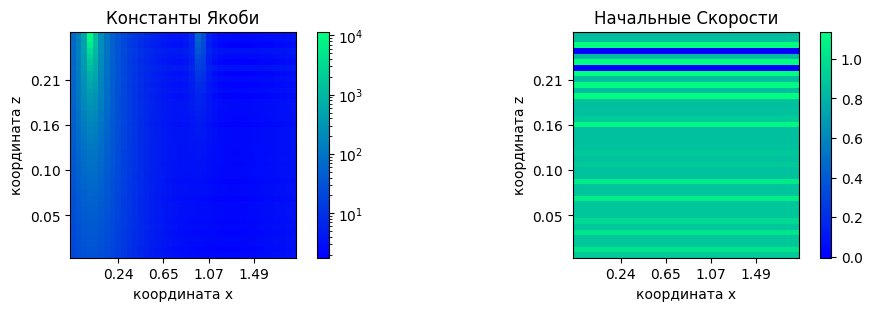

In [32]:
grafics(40)

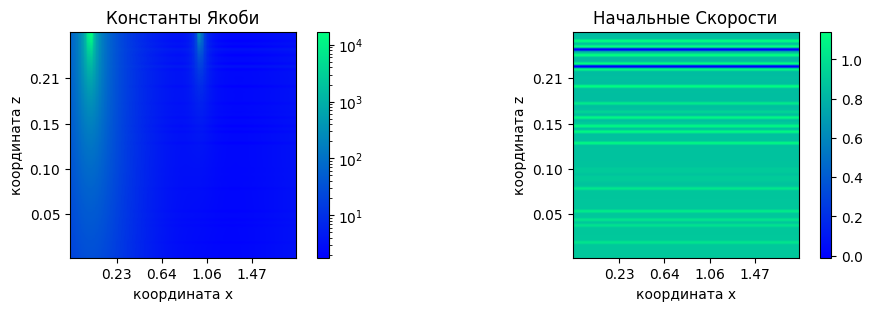

In [33]:
grafics(80)

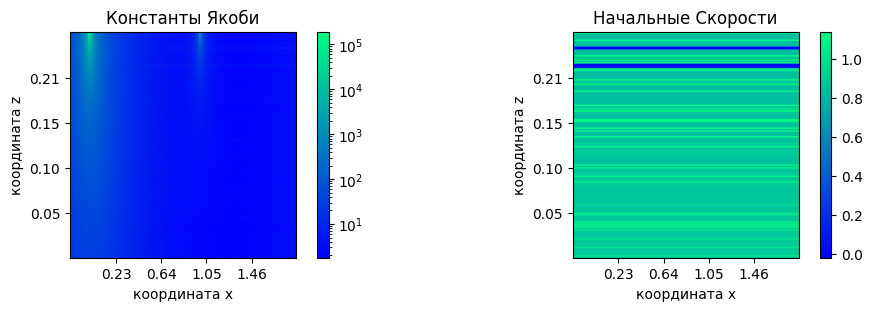

In [34]:
grafics(160)

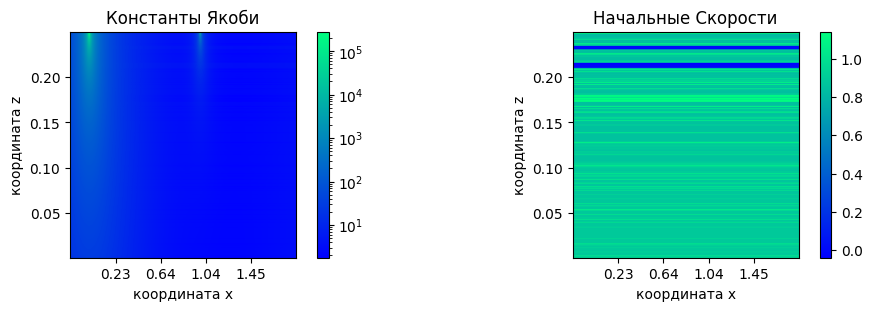

In [39]:
grafics(320)